In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_file = 'result.csv'
# result_file = 'result_success.csv'

In [23]:
df_loaded = pd.read_csv("data_9992_1/performance.log")
data = (
    df_loaded.assign(
        average_reward=df_loaded["total_reward"] / df_loaded["steps"].replace(0, pd.NA)
    )
    .fillna(0)
    .groupby("name")
    .agg({
        "steps": list,
        "average_reward": list,
        "success": list,
        "smoothness": list,
        "heading_deviation": list
    })
    .to_dict("index")
)


with open(result_file, 'w') as f:
    f.write("Model,horizon,obs,AvgReward,Steps,Success,Smooth,Deviation\n")
    for key, value in data.items():
        #convert
        steps = np.mean(value['steps'])
        mean_reward = np.mean(value['average_reward'])
        #count success over length of np array
        success = np.sum(value['success'])/ len(value['success'])
        smoothness = np.mean(value['smoothness'])
        heading_deviation = np.mean(value['heading_deviation'])

        #look for 'obs' in key and get the immediate number after it
        obs = key.lower().split('obs')[-1][:2]

        horizon = 0
        if 'Right' in key:
            key = 'Right'
        elif 'Left' in key:
            key = 'Left'
        elif 'Steering' in key:
            key = 'Steering'
        elif 'dreamer' in key:
            key = 'Dreamer30'
            horizon = 30

        f.write(f"{key},{horizon},{obs},{mean_reward},{steps},{success},{smoothness},{heading_deviation}\n")

In [25]:
#read csv file into a pandas DataFrame
raw_data = pd.read_csv(result_file)
print(raw_data.shape)
print(raw_data)

(12, 8)
        Model  horizon  obs  AvgReward   Steps  Success       Smooth  \
0   Dreamer30       30   10  -0.018202  802.43     0.63   890.049525   
1   Dreamer30       30   20  -0.017317  604.37     0.68   486.177603   
2   Dreamer30       30   30  -0.032228  678.86     0.19   663.234473   
3        Left        0   10  -0.018541  971.14     0.51   969.447007   
4       Right        0   10  -0.020763  640.05     0.67   447.799611   
5    Steering        0   10  -0.025138  870.22     0.50  1142.167308   
6        Left        0   20  -0.023862  643.28     0.60   413.264171   
7       Right        0   20  -0.021438  614.28     0.58   538.257167   
8    Steering        0   20  -0.026268  497.75     0.52   486.134590   
9        Left        0   30  -0.033420  527.60     0.30   562.950814   
10      Right        0   30  -0.030946  691.59     0.18   910.628104   
11   Steering        0   30  -0.033346  736.01     0.17   608.165106   

    Deviation  
0    4.863730  
1    5.208049  
2    3.

In [26]:
colors1 = plt.cm.Blues(np.linspace(0.4, 0.8, 4))
colors2 = plt.cm.Greens(np.linspace(0.4, 0.8, 4))

compare_series1 = {
    'Right': colors1[0],
    'Left': colors1[1],
    'Steering': colors1[2],
    # 'Dreamerdreamer_obs10': colors2[0],
    # 'Dreamerdreamer_obs20': colors2[1],
    # 'Dreamerdreamer_obs30': colors2[2],
    'Dreamer30': 'green'
}

In [27]:
data = raw_data[raw_data['Model'].isin(compare_series1.keys())]
# remove horizon column group by model and obs to forma a pivot table
data = data.drop(columns=['horizon'])
data = data.pivot_table(index='Model', columns='obs', values=['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation'], aggfunc=np.mean)
for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    print(data[metric])

obs              10        20        30
Model                                  
Dreamer30 -0.018202 -0.017317 -0.032228
Left      -0.018541 -0.023862 -0.033420
Right     -0.020763 -0.021438 -0.030946
Steering  -0.025138 -0.026268 -0.033346
obs            10      20      30
Model                            
Dreamer30  802.43  604.37  678.86
Left       971.14  643.28  527.60
Right      640.05  614.28  691.59
Steering   870.22  497.75  736.01
obs          10    20    30
Model                      
Dreamer30  0.63  0.68  0.19
Left       0.51  0.60  0.30
Right      0.67  0.58  0.18
Steering   0.50  0.52  0.17
obs                 10          20          30
Model                                         
Dreamer30   890.049525  486.177603  663.234473
Left        969.447007  413.264171  562.950814
Right       447.799611  538.257167  910.628104
Steering   1142.167308  486.134590  608.165106
obs              10        20        30
Model                                  
Dreamer30  4.863730  5.208

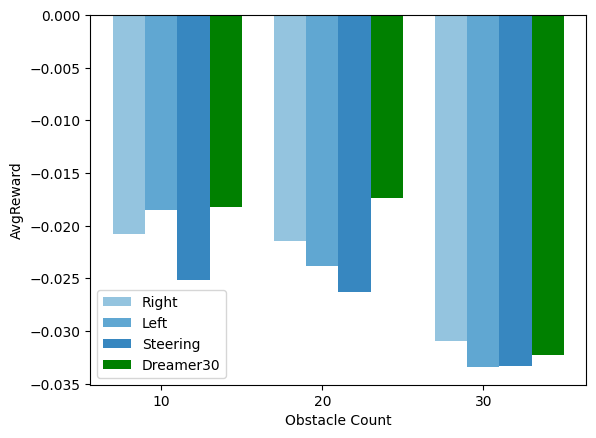

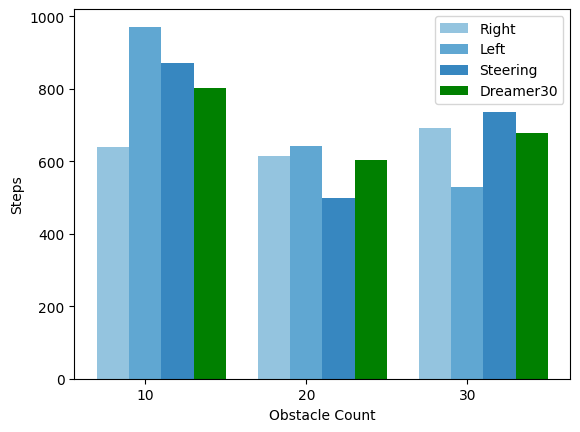

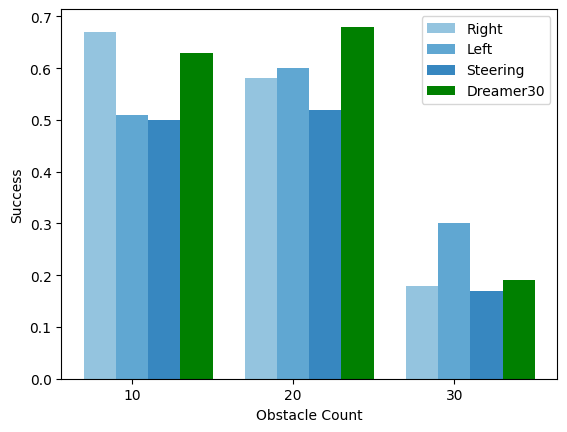

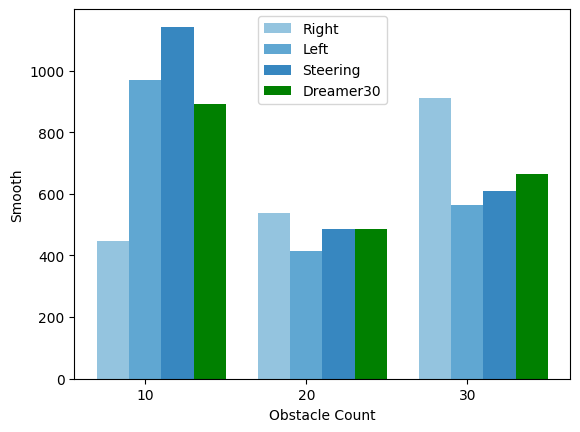

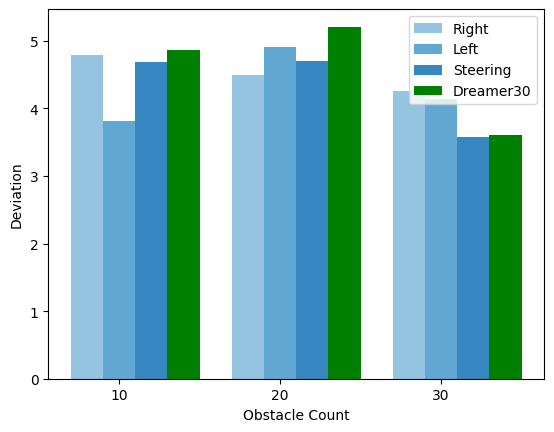

In [28]:
#for each metric, plot a single grouped bar chart base on obstacle count
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series1.keys())]

obs = data['obs'].unique()
x = np.arange(len(obs))
bar_width = 0.2

# for metric in ['AvgReward']:#, 'Steps', 'Success', 'Smooth', 'Deviation']:
for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for i, (model, color) in enumerate(compare_series1.items()):
        vals = [data[(data['Model'] == model) & (data['obs'] == o)][metric].values[0] if not data[(data['Model'] == model) & (data['obs'] == o)].empty else 0 for o in obs]
        plt.bar(x + i * bar_width, vals, width=bar_width, label=model, color=color)

    plt.xticks(x + bar_width, obs)
    plt.xlabel('Obstacle Count')
    plt.ylabel(metric)
    plt.legend()
    plt.savefig(f'result_{metric.lower()}_compare_plot.png')
    plt.show()

In [23]:
colors2 = plt.cm.Greens(np.linspace(0.3, 1.0, 5))

compare_series2 = {
    'Dreamer10': colors2[0],
    'Dreamer20': colors2[1],
    'Dreamer30': colors2[2],
    'Dreamer40': colors2[3],
    'Dreamer50': colors2[4]
}

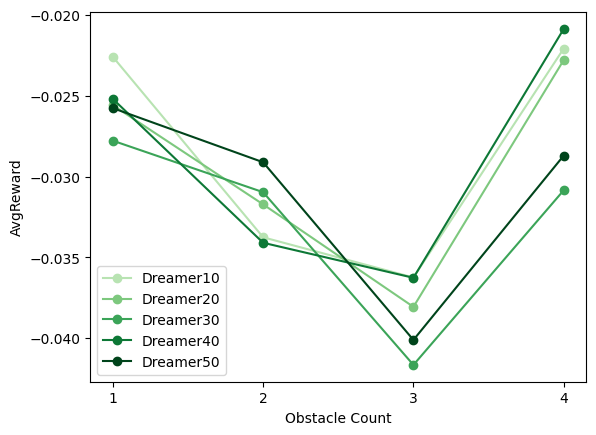

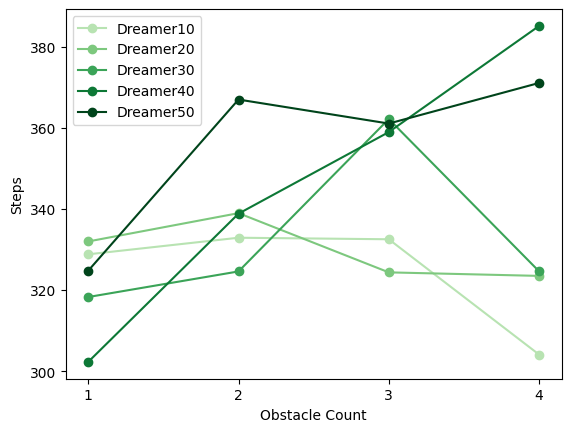

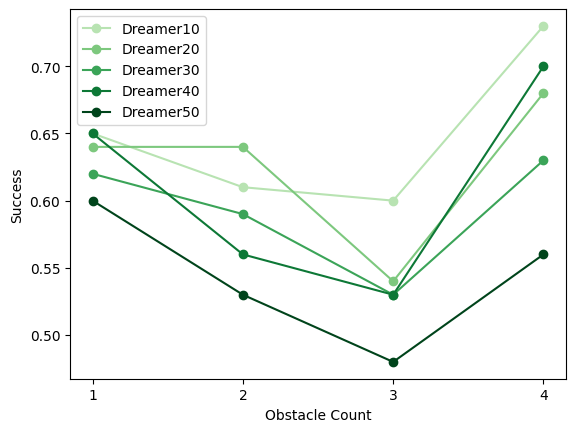

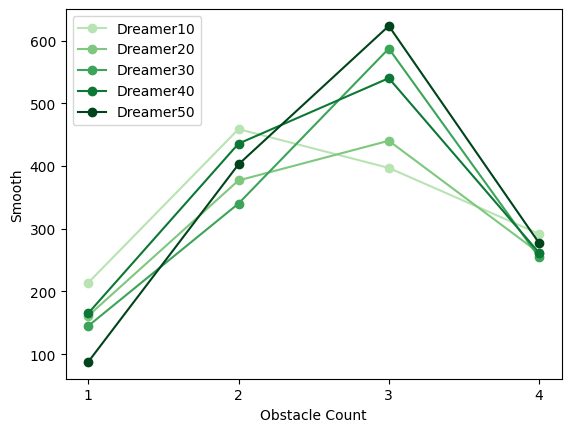

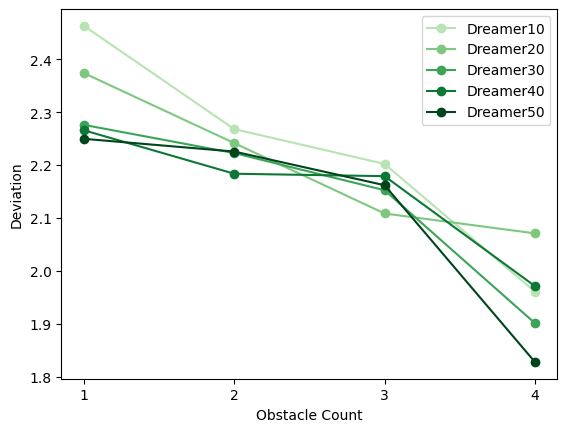

In [100]:
#for each metric, plot a single line chart along the obstacle count
#each model is a separate line
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series2.keys())]

obs = data['obs'].unique()
x = np.arange(len(obs))

for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for i, (model, color) in enumerate(compare_series2.items()):
        vals = [data[(data['Model'] == model) & (data['obs'] == o)][metric].values[0] if not data[(data['Model'] == model) & (data['obs'] == o)].empty else 0 for o in obs]
        plt.plot(x, vals, label=model, color=color, marker='o')

    plt.xticks(x, obs)
    plt.xlabel('Obstacle Count')
    plt.ylabel(metric)
    plt.legend()
    plt.savefig(f'result_{metric.lower()}_dreamer_plot.png')
    plt.show()

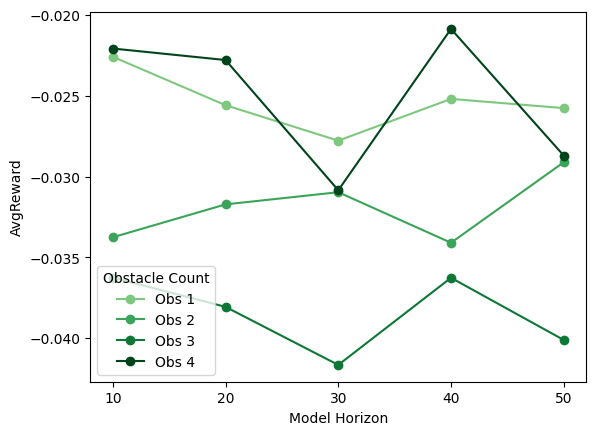

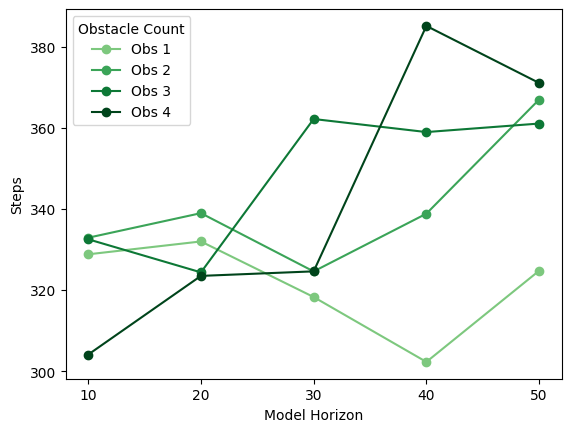

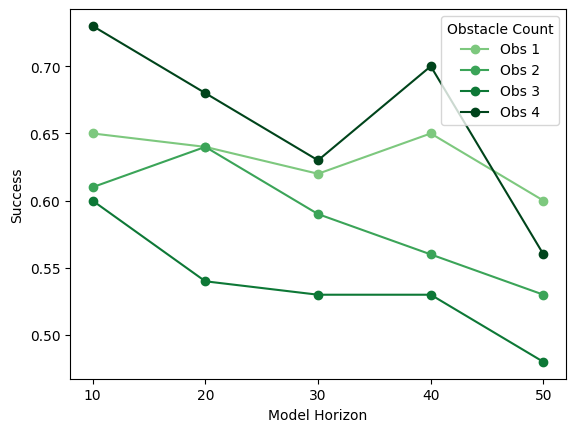

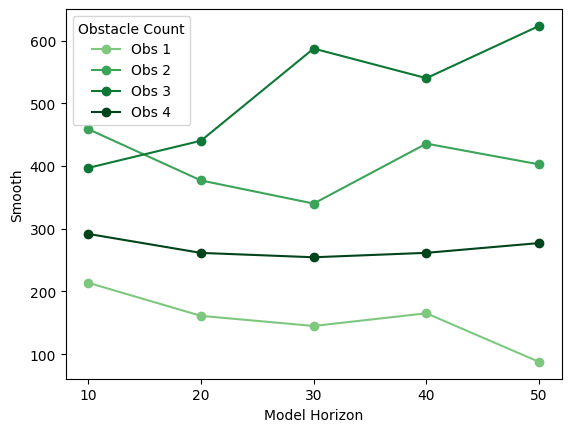

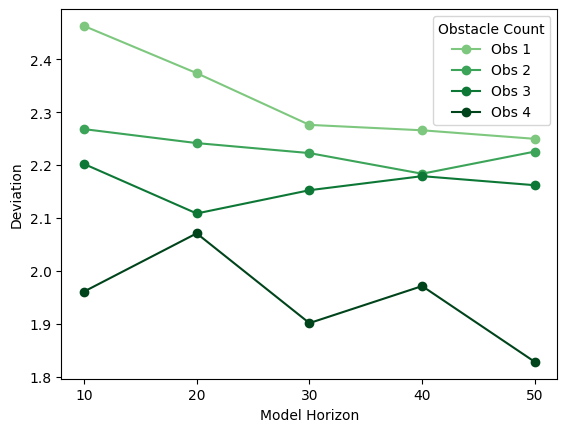

In [24]:
#for each metric, plot a single line chart along the obstacle count
#each model is a separate line
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series2.keys())]

horizons = [10, 20, 30, 40, 50]
x = np.arange(len(horizons))

for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for obs_count in data['obs'].unique():
        vals = [data[(data['obs'] == obs_count) & (data['horizon'] == h)][metric].values[0] 
                if not data[(data['obs'] == obs_count) & (data['horizon'] == h)].empty else 0 
                for h in horizons]
        plt.plot(x, vals, label=f'Obs {obs_count}',color=colors2[obs_count], marker='o')

    plt.xticks(x, horizons)
    plt.xlabel('Model Horizon')
    plt.ylabel(metric)
    plt.legend(title='Obstacle Count')
    plt.savefig(f'result_{metric.lower()}_horizon_plot.png')
    plt.show()